In [1]:
# Evaluation (Target: CICIDS2017)
# Loads models trained on NSL-KDD and evaluates them on CICIDS2017 (cross-dataset generalization).

In [2]:
# --- Cell 1: Setup & Load Artifacts ---
import pandas as pd
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import joblib

from torch_geometric.nn import GCNConv, GATConv, SAGEConv
from torch_geometric.data import Data
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

class GNNModel(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, model_type='GCN'):
        super(GNNModel, self).__init__()
        if model_type == 'GCN':
            self.conv1 = GCNConv(input_dim, hidden_dim)
            self.conv2 = GCNConv(hidden_dim, output_dim)
        elif model_type == 'GAT':
            self.conv1 = GATConv(input_dim, hidden_dim, heads=8, concat=True)
            self.conv2 = GATConv(hidden_dim * 8, output_dim, heads=1, concat=False)
        elif model_type == 'SAGE':
            self.conv1 = SAGEConv(input_dim, hidden_dim)
            self.conv2 = SAGEConv(hidden_dim, output_dim)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)

@torch.no_grad()
def evaluate(model, data):
    model.eval()
    out    = model(data)
    preds  = out.argmax(dim=1)
    y_true = data.y
    return {
        'accuracy':  accuracy_score(y_true.cpu(), preds.cpu()),
        'f1':        f1_score(y_true.cpu(), preds.cpu(), zero_division=0),
        'precision': precision_score(y_true.cpu(), preds.cpu(), zero_division=0),
        'recall':    recall_score(y_true.cpu(), preds.cpu(), zero_division=0)
    }

scaler = joblib.load('ids_scaler.pkl')
print('Scaler loaded.')

Scaler loaded.


In [3]:
# --- Cell 2: Load & Preprocess CICIDS2017 ---
df_cic = pd.read_csv('Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv')

# Strip leading/trailing whitespace from column names (common in CICIDS CSVs)
df_cic.columns = df_cic.columns.str.strip()

# Map CICIDS column names to the common feature names used in training
# 'intent-based' mapping: closest equivalents to NSL-KDD's duration/src_bytes/dst_bytes/count/srv_count
rename_dict = {
    'Flow Duration':          'duration',
    'Total Fwd Packets':      'src_bytes',
    'Total Backward Packets': 'dst_bytes',
    'Fwd Packet Length Mean': 'count',
    'Bwd Packet Length Mean': 'srv_count'
}
df_cic = df_cic.rename(columns=rename_dict)

COMMON_FEATURES = ['duration', 'src_bytes', 'dst_bytes', 'count', 'srv_count']

missing = [f for f in COMMON_FEATURES if f not in df_cic.columns]
if missing:
    print(f'ERROR: Missing columns: {missing}')
    print('Available columns:', df_cic.columns.tolist())
else:
    print('All features aligned.')

# Binary labels: BENIGN=0, anything else=1
df_cic['label_binary'] = (df_cic['Label'] != 'BENIGN').astype(int)
y_cic = df_cic['label_binary'].values

X_cic = df_cic[COMMON_FEATURES].fillna(0)

# FIX: Replace inf values that are common in CICIDS packet-length features
X_cic = X_cic.replace([np.inf, -np.inf], 0)

X_cic_scaled = scaler.transform(X_cic)
print(f'Rows: {len(df_cic)} | Label distribution: {pd.Series(y_cic).value_counts().to_dict()}')

All features aligned.
Rows: 286467 | Label distribution: {1: 158930, 0: 127537}


In [4]:
# --- Cell 3: Graph Construction ---
# Sequential edges (row i -> row i+1) so num_nodes == len(df_cic) == feature matrix size.
# This is consistent with Notebook 1 and UNSW eval notebook.

num_nodes  = len(df_cic)
src_nodes  = np.arange(0, num_nodes - 1)
dst_nodes  = np.arange(1, num_nodes)
edge_index = torch.tensor([src_nodes, dst_nodes], dtype=torch.long)

cic_graph_data = Data(
    x=torch.tensor(X_cic_scaled, dtype=torch.float),
    edge_index=edge_index,
    y=torch.tensor(y_cic, dtype=torch.long)
)

print(f'Graph: {cic_graph_data.num_nodes} nodes, {cic_graph_data.num_edges} edges')
assert cic_graph_data.num_nodes == len(df_cic), 'Node count mismatch!'

Graph: 286467 nodes, 286466 edges


C:\Users\ceb1003\AppData\Local\Temp\ipykernel_27540\994104054.py:8: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:256.)
  edge_index = torch.tensor([src_nodes, dst_nodes], dtype=torch.long)


In [5]:
# --- Cell 4: Evaluate All Models on CICIDS2017 ---
model_types = ['GCN', 'GAT', 'SAGE']
cic_results = {}

for m_type in model_types:
    print(f'--- Evaluating {m_type} ---')
    model = GNNModel(input_dim=len(COMMON_FEATURES), hidden_dim=64, output_dim=2, model_type=m_type)
    weights_path = f'gnn_model_{m_type.lower()}.pt'
    try:
        model.load_state_dict(torch.load(weights_path))
        model.eval()
        cic_results[m_type] = evaluate(model, cic_graph_data)
        print(f'  Success.')
    except FileNotFoundError:
        print(f'  Error: {weights_path} not found. Run NSLKDDCoreTraining first.')
    except Exception as e:
        print(f'  Error with {m_type}: {e}')

--- Evaluating GCN ---
  Success.
--- Evaluating GAT ---
  Success.
--- Evaluating SAGE ---
  Success.


In [6]:
# --- Cell 5: Print Results ---
print('CICIDS2017 Cross-Dataset Results (Trained on NSL-KDD):')
for m_type, metrics in cic_results.items():
    print(f'\n{m_type}:')
    for metric, value in metrics.items():
        print(f'  {metric.capitalize()}: {value:.4f}')

CICIDS2017 Cross-Dataset Results (Trained on NSL-KDD):

GCN:
  Accuracy: 0.0997
  F1: 0.0153
  Precision: 0.0194
  Recall: 0.0126

GAT:
  Accuracy: 0.0950
  F1: 0.0157
  Precision: 0.0198
  Recall: 0.0130

SAGE:
  Accuracy: 0.1652
  F1: 0.0059
  Precision: 0.0087
  Recall: 0.0045


      accuracy        f1  precision    recall
GCN   0.099676  0.015265   0.019411  0.012578
GAT   0.095048  0.015681   0.019772  0.012993
SAGE  0.165192  0.005919   0.008721  0.004480


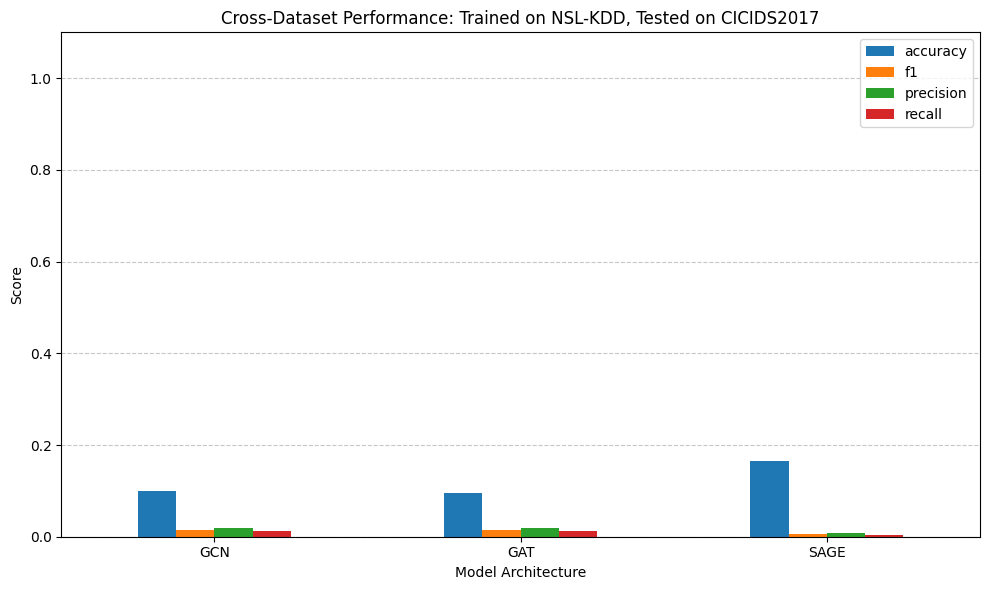

In [7]:
# --- Cell 6: Plot ---
if cic_results:
    df_compare_cic = pd.DataFrame(cic_results).T
    print(df_compare_cic)
    fig, ax = plt.subplots(figsize=(10, 6))
    df_compare_cic.plot(kind='bar', ax=ax)
    ax.set_title('Cross-Dataset Performance: Trained on NSL-KDD, Tested on CICIDS2017')
    ax.set_ylabel('Score')
    ax.set_xlabel('Model Architecture')
    ax.set_ylim(0, 1.1)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.legend(loc='upper right')
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print('No results to plot.')